In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ilhamhasib/vehicle-classification-dataset/Vehicle Test Data/SUV/89.jpg
/kaggle/input/datasets/ilhamhasib/vehicle-classification-dataset/Vehicle Test Data/SUV/84.jpg
/kaggle/input/datasets/ilhamhasib/vehicle-classification-dataset/Vehicle Test Data/SUV/85.jpg
/kaggle/input/datasets/ilhamhasib/vehicle-classification-dataset/Vehicle Test Data/SUV/82.jpg
/kaggle/input/datasets/ilhamhasib/vehicle-classification-dataset/Vehicle Test Data/SUV/81.jpg
/kaggle/input/datasets/ilhamhasib/vehicle-classification-dataset/Vehicle Test Data/SUV/80.jpg
/kaggle/input/datasets/ilhamhasib/vehicle-classification-dataset/Vehicle Test Data/SUV/88.jpg
/kaggle/input/datasets/ilhamhasib/vehicle-classification-dataset/Vehicle Test Data/SUV/83.jpg
/kaggle/input/datasets/ilhamhasib/vehicle-classification-dataset/Vehicle Test Data/SUV/86.jpg
/kaggle/input/datasets/ilhamhasib/vehicle-classification-dataset/Vehicle Test Data/SUV/87.jpg
/kaggle/input/datasets/ilhamhasib/vehicle-classification-dat

In [2]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))
print("GPU count:", torch.cuda.device_count())

CUDA available: True
GPU: Tesla T4
GPU count: 2


In [3]:
import os

# Set the correct dataset path
DATASET_PATH = "/kaggle/input/datasets/ilhamhasib/vehicle-classification-dataset"

print("Dataset path set to:", DATASET_PATH)
print("Path exists:", os.path.exists(DATASET_PATH))

if os.path.exists(DATASET_PATH):
    print("Contents:", os.listdir(DATASET_PATH))
    
    # Check for train folder
    for item in os.listdir(DATASET_PATH):
        item_path = os.path.join(DATASET_PATH, item)
        if os.path.isdir(item_path):
            print("\nFolder:", item)
            print("  Sub-items:", os.listdir(item_path)[:10])

Dataset path set to: /kaggle/input/datasets/ilhamhasib/vehicle-classification-dataset
Path exists: True
Contents: ['Vehicle Test Data', 'Car-Classification-Data-with-Labels-iHasib']

Folder: Vehicle Test Data
  Sub-items: ['SUV', 'BUS', 'Truck', 'MPV', 'Sedan', 'Hatchback', 'Pickup', 'Easy-Bike', 'CNG', 'Bike']

Folder: Car-Classification-Data-with-Labels-iHasib
  Sub-items: ['type-labels.csv', 'Train']


In [4]:
import torch
import torchvision.models as models

# Try loading without downloading (use cached weights if available)
try:
    model = models.resnet18(weights=None)  # No weights first
    print("Model architecture loaded successfully")
    
    # Check if weights are already cached
    import os
    cache_dir = os.path.expanduser("~/.cache/torch/hub/checkpoints/")
    if os.path.exists(cache_dir):
        print("Cache directory exists:", cache_dir)
        print("Cached files:", os.listdir(cache_dir)[:5])
except Exception as e:
    print("Error:", e)

Model architecture loaded successfully


In [5]:
# ==============================================================================
# CELL 1: IMPORTS & ENVIRONMENT SETUP
# ==============================================================================
import os
import json
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.models as models
from torchvision import transforms

from sklearn.metrics import (
    classification_report, confusion_matrix, 
    roc_curve, auc, precision_recall_fscore_support
)
from sklearn.preprocessing import label_binarize

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [6]:
# ==============================================================================
# CELL 2: AUTO-DETECT DATASET PATH (DEEP SEARCH VERSION)
# ==============================================================================
"""
This cell automatically finds your dataset by searching DEEP into subfolders.
Handles nested paths like /kaggle/input/datasets/username/dataset-name/
"""

def find_dataset_path():
    """Auto-detect dataset path with deep recursive search."""

    # Possible base paths in Kaggle
    possible_bases = [
        "/kaggle/input/",
        "../input/",
        "./input/",
        "/kaggle/working/",
    ]

    # Keywords that indicate a vehicle dataset
    dataset_keywords = ['vehicle', 'car', 'sedan', 'suv', 'truck', 'bus', 'motorcycle', 'auto']
    class_keywords = ['sedan', 'suv', 'truck', 'bus', 'motorcycle', 'car', 'van', 'pickup']

    def search_directory(path, depth=0, max_depth=4):
        """Recursively search for dataset structure."""
        if depth > max_depth or not os.path.isdir(path):
            return None

        try:
            items = os.listdir(path)
        except PermissionError:
            return None

        # Check if this directory looks like a dataset root
        # Look for train/test folders or class folders
        has_train = any('train' in item.lower() for item in items if os.path.isdir(os.path.join(path, item)))
        has_test = any('test' in item.lower() for item in items if os.path.isdir(os.path.join(path, item)))

        # Check if subfolders look like class names
        subdirs = [item for item in items if os.path.isdir(os.path.join(path, item))]
        looks_like_classes = any(
            any(kw in sub.lower() for kw in class_keywords)
            for sub in subdirs
        )

        # If we found train/test or class-like folders, this is likely our dataset
        if has_train or has_test or looks_like_classes:
            # Verify by checking if subdirs contain images
            for sub in subdirs[:3]:  # Check first 3 subdirs
                sub_path = os.path.join(path, sub)
                try:
                    sub_items = os.listdir(sub_path)[:5]
                    has_images = any(item.lower().endswith(('.png', '.jpg', '.jpeg')) for item in sub_items)
                    if has_images:
                        print("\n[FOUND] Dataset at:", path)
                        print("  Structure:", subdirs[:5])
                        return path
                except:
                    continue

        # Recurse into subdirectories
        for item in items:
            item_path = os.path.join(path, item)
            if os.path.isdir(item_path) and not item.startswith('.'):
                # Check if folder name suggests it's a dataset
                if any(kw in item.lower() for kw in dataset_keywords) or depth < 2:
                    result = search_directory(item_path, depth + 1, max_depth)
                    if result:
                        return result

        return None

    # Search from each base path
    for base in possible_bases:
        if os.path.exists(base):
            print("Searching from:", base)
            result = search_directory(base)
            if result:
                return result

    return None

# Try auto-detection
DATASET_PATH = find_dataset_path()

Searching from: /kaggle/input/

[FOUND] Dataset at: /kaggle/input/datasets/ilhamhasib/vehicle-classification-dataset/Vehicle Test Data
  Structure: ['SUV', 'BUS', 'Truck', 'MPV', 'Sedan']


In [7]:
# ==============================================================================
# CELL 3: MANUAL PATH SETTING (USE THIS IF AUTO-DETECT FAILS)
# ==============================================================================
"""
INSTRUCTIONS:
If auto-detect failed above, look at the right sidebar under "Input" 
and find the exact path to your dataset.

Common Kaggle paths look like:
  /kaggle/input/vehicle-type-recognition/
  /kaggle/input/datasets/username/vehicle-classification-dataset/
  /kaggle/input/vehicle-dataset/

Uncomment the line below and paste your exact path.
"""

# MANUAL OVERRIDE - Uncomment and set your exact path:
# DATASET_PATH = "/kaggle/input/datasets/ilhamhasib/vehicle-classification-dataset"

# If auto-detect failed and you haven't set manual path, raise error
if DATASET_PATH is None:
    print("\n" + "="*60)
    print("AUTO-DETECT FAILED")
    print("="*60)
    print("\nPlease set DATASET_PATH manually.")
    print("\nStep 1: Look at the right sidebar -> 'Input'")
    print("Step 2: Note the exact folder name/path")
    print("Step 3: Uncomment the line above and set it")
    print("\nExample:")
    print('  DATASET_PATH = "/kaggle/input/datasets/ilhamhasib/vehicle-classification-dataset"')
    print("="*60)
    raise ValueError("Please set DATASET_PATH manually in Cell 3 above!")

print("\n" + "="*60)
print("DATASET PATH CONFIRMED")
print("="*60)
print("Path:", DATASET_PATH)
print("Exists:", os.path.exists(DATASET_PATH))


DATASET PATH CONFIRMED
Path: /kaggle/input/datasets/ilhamhasib/vehicle-classification-dataset/Vehicle Test Data
Exists: True


In [8]:
# ==============================================================================
# CELL 4: EXPLORE DATASET STRUCTURE
# ==============================================================================

def explore_structure(path, indent=0):
    """Recursively print dataset structure."""
    items = os.listdir(path)
    for item in sorted(items):
        item_path = os.path.join(path, item)
        prefix = "  " * indent
        if os.path.isdir(item_path):
            subitems = os.listdir(item_path)
            print(prefix + "[" + item + "]/ (" + str(len(subitems)) + " items)")
            # Only go 2 levels deep to avoid spam
            if indent < 2:
                explore_structure(item_path, indent + 1)
        else:
            if indent < 2:  # Only show files at top levels
                print(prefix + item)

print("\nDataset structure:")
explore_structure(DATASET_PATH)


Dataset structure:
[BUS]/ (10 items)
  10.jpg
  11.jpg
  12.jpg
  13.jpg
  14.jpg
  15.jpg
  16.jpg
  17.jpg
  18.jpg
  19.jpg
[Bike]/ (10 items)
  0.jpg
  1.jpg
  2.jpg
  3.jpg
  4.jpg
  5.jpg
  6.jpg
  7.jpg
  8.jpg
  9.jpg
[CNG]/ (10 items)
  20.jpg
  21.jpg
  22.jpg
  23.jpg
  24.jpg
  25.png
  26.jpg
  27.jpg
  28.png
  29.jpg
[Easy-Bike]/ (10 items)
  30.jpg
  31.jpg
  32.jpg
  33.jpg
  34.jpg
  35.jpg
  36.jpg
  37.jpg
  38.jpg
  39.jpg
[Hatchback]/ (10 items)
  40.jpg
  41.jpg
  42.jpg
  43.jpg
  44.jpg
  45.jpg
  46.jpg
  47.jpg
  48.jpg
  49.jpg
[MPV]/ (10 items)
  50.jpg
  51.jpg
  52.jpg
  53.jpg
  54.jpg
  55.jpg
  56.jpg
  57.jpg
  58.jpg
  59.jpg
[Pickup]/ (10 items)
  60.jpg
  61.jpg
  62.jpg
  63.jpg
  64.jpg
  65.jpg
  66.jpg
  67.jpg
  68.jpg
  69.jpg
[SUV]/ (10 items)
  80.jpg
  81.jpg
  82.jpg
  83.jpg
  84.jpg
  85.jpg
  86.jpg
  87.jpg
  88.jpg
  89.jpg
[Sedan]/ (10 items)
  70.jpg
  71.jpg
  72.jpg
  73.jpg
  74.jpg
  75.jpg
  76.jpg
  77.jpg
  78.jpg
  79.jpg


In [9]:
# ==============================================================================
# CELL 5: CUSTOM DATASET CLASS
# ==============================================================================
class VehicleDataset(Dataset):
    """
    Custom PyTorch Dataset for Vehicle Type Classification.

    Inherits from torch.utils.data.Dataset to provide standard interface
    for DataLoader to batch, shuffle, and parallel-load images.

    Args:
        data_dir (str): Path to dataset split
        transform (callable): Image preprocessing pipeline

    Returns:
        tuple: (image_tensor, label_integer)
    """
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        # Each subfolder name = class label
        # sorted() ensures consistent class ordering across runs
        self.classes = sorted([d for d in os.listdir(data_dir) 
                               if os.path.isdir(os.path.join(data_dir, d))])

        # Map class names to integer indices
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.idx_to_class = {i: cls_name for cls_name, i in self.class_to_idx.items()}

        # Traverse each class folder and collect image paths
        for cls_name in self.classes:
            cls_dir = os.path.join(data_dir, cls_name)
            for img_name in sorted(os.listdir(cls_dir)):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths.append(os.path.join(cls_dir, img_name))
                    self.labels.append(self.class_to_idx[cls_name])

        print("Loaded", len(self.image_paths), "images from", data_dir)
        print("Classes:", self.classes)
        print("Class mapping:", self.class_to_idx)

    def __len__(self):
        """Return total number of samples in dataset.

        DataLoader uses this to know how many batches to create.
        """
        return len(self.image_paths)

    def __getitem__(self, idx):
        """Load and return a single sample by index.

        Args:
            idx (int): Index of sample to retrieve

        Returns:
            tuple: (image_tensor, label_integer)
                - image_tensor: torch.Tensor of shape (3, 224, 224)
                - label_integer: int in range [0, num_classes-1]
        """
        # 1. Load image from disk using PIL
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")

        # 2. Retrieve corresponding label
        label = self.labels[idx]

        # 3. Apply preprocessing transform
        if self.transform:
            image = self.transform(image)

        return image, label

In [10]:
# ==============================================================================
# CELL 6: CUSTOM DATASET CLASS (hardcoded CSV mode)
# ==============================================================================
import pandas as pd

# Hardcoded paths
train_dir = "/kaggle/input/datasets/ilhamhasib/vehicle-classification-dataset/Car-Classification-Data-with-Labels-iHasib/Train"
test_dir  = "/kaggle/input/datasets/ilhamhasib/vehicle-classification-dataset/Vehicle Test Data"
csv_path  = "/kaggle/input/datasets/ilhamhasib/vehicle-classification-dataset/Car-Classification-Data-with-Labels-iHasib/type-labels.csv"

# Load CSV once globally so the class can access it
_df = pd.read_csv(csv_path)
_df['Type'] = _df['Type'].str.strip()
_CLASSES = sorted(_df['Type'].unique().tolist())
_CLASS_TO_IDX = {cls: i for i, cls in enumerate(_CLASSES)}
_IDX_TO_CLASS = {i: cls for cls, i in _CLASS_TO_IDX.items()}

print("Classes found:", _CLASSES)
print("Total CSV rows:", len(_df))

class VehicleDataset(Dataset):
    def __init__(self, data_dir, use_csv=False, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        if use_csv:
            # Training data: use globally loaded CSV
            self.classes = _CLASSES
            self.class_to_idx = _CLASS_TO_IDX
            self.idx_to_class = _IDX_TO_CLASS

            for _, row in _df.iterrows():
                img_path = os.path.join(data_dir, str(int(row['ID'])) + '.jpg')
                self.image_paths.append(img_path)
                self.labels.append(self.class_to_idx[row['Type']])

        else:
            # Test data: labels from folder names
            self.classes = sorted([
                d for d in os.listdir(data_dir)
                if os.path.isdir(os.path.join(data_dir, d))
            ])
            self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
            self.idx_to_class = {i: cls for cls, i in self.class_to_idx.items()}

            for cls_name in self.classes:
                cls_dir = os.path.join(data_dir, cls_name)
                for img_name in sorted(os.listdir(cls_dir)):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.image_paths.append(os.path.join(cls_dir, img_name))
                        self.labels.append(self.class_to_idx[cls_name])

        print("Loaded", len(self.image_paths), "images |", len(self.classes), "classes")
        print("Classes:", self.classes)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

print("VehicleDataset class ready.")

Classes found: ['Bike', 'Bus', 'CNG', 'Easy-Bike', 'Hatchback', 'MPV', 'Pickup', 'SEDAN', 'SUV', 'Truck']
Total CSV rows: 6480
VehicleDataset class ready.


In [11]:
# ==============================================================================
# CELL 7: SAVE CLASS MAPPING & CREATE TEMP DATASET
# ==============================================================================
# Create temporary dataset to get class mapping
temp_dataset = VehicleDataset(train_dir, use_csv=True)

# Save mapping to JSON for inference script
mapping = {
    "class_to_idx": temp_dataset.class_to_idx,
    "idx_to_class": temp_dataset.idx_to_class,
    "classes": temp_dataset.classes
}

with open("class_mapping.json", "w") as f:
    json.dump(mapping, f, indent=2)

print("\nSaved class_mapping.json:")
print(json.dumps(mapping, indent=2))

Loaded 6480 images | 10 classes
Classes: ['Bike', 'Bus', 'CNG', 'Easy-Bike', 'Hatchback', 'MPV', 'Pickup', 'SEDAN', 'SUV', 'Truck']

Saved class_mapping.json:
{
  "class_to_idx": {
    "Bike": 0,
    "Bus": 1,
    "CNG": 2,
    "Easy-Bike": 3,
    "Hatchback": 4,
    "MPV": 5,
    "Pickup": 6,
    "SEDAN": 7,
    "SUV": 8,
    "Truck": 9
  },
  "idx_to_class": {
    "0": "Bike",
    "1": "Bus",
    "2": "CNG",
    "3": "Easy-Bike",
    "4": "Hatchback",
    "5": "MPV",
    "6": "Pickup",
    "7": "SEDAN",
    "8": "SUV",
    "9": "Truck"
  },
  "classes": [
    "Bike",
    "Bus",
    "CNG",
    "Easy-Bike",
    "Hatchback",
    "MPV",
    "Pickup",
    "SEDAN",
    "SUV",
    "Truck"
  ]
}


In [12]:
# ==============================================================================
# CELL 8: DATA TRANSFORMS
# ==============================================================================
"""
TRANSFORM RATIONALE:
- Resize(224, 224): ResNet18 was pre-trained on ImageNet at 224x224 resolution.
  Input must match or the architecture's fully-connected layer dimensions break.

- ToTensor(): Converts PIL Image (H x W x C, uint8 [0,255]) to 
  torch.Tensor (C x H x W, float32 [0.0, 1.0]). Neural networks require tensors.

- Normalize(mean, std): ImageNet pre-training used these statistics.
  Normalizing to same distribution improves transfer learning convergence.
  mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]

- RandomHorizontalFlip (train only): Data augmentation. 50% chance to mirror
  image horizontally. Vehicles look the same from left/right, so this is safe
  and effectively doubles training data diversity.

- ColorJitter (train only): Randomly perturbs brightness, contrast, saturation.
  Makes model robust to different lighting conditions.
"""

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

In [13]:
# ==============================================================================
# CELL 9: DATASET SPLITTING (TRAIN / VAL / TEST)
# ==============================================================================
from torch.utils.data import Subset

# Reference dataset for size and class info only
ref_dataset = VehicleDataset(train_dir, use_csv=True)
total_size  = len(ref_dataset)
train_size  = int(0.70 * total_size)
val_size    = int(0.15 * total_size)
test_size   = total_size - train_size - val_size

print("Total:", total_size, "| Train:", train_size, "| Val:", val_size, "| Test:", test_size)

# Reproducible shuffle
shuffled      = torch.randperm(total_size, generator=torch.Generator().manual_seed(42)).tolist()
train_indices = shuffled[:train_size]
val_indices   = shuffled[train_size: train_size + val_size]
test_indices  = shuffled[train_size + val_size:]

# Three separate instances — each with its own transform
train_base = VehicleDataset(train_dir, use_csv=True, transform=train_transform)
val_base   = VehicleDataset(train_dir, use_csv=True, transform=val_test_transform)
test_base  = VehicleDataset(train_dir, use_csv=True, transform=val_test_transform)

train_dataset = Subset(train_base, train_indices)
val_dataset   = Subset(val_base,   val_indices)
test_dataset  = Subset(test_base,  test_indices)

class_names = ref_dataset.classes
NUM_CLASSES = len(class_names)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print("Train batches:", len(train_loader),
      "| Val batches:", len(val_loader),
      "| Test batches:", len(test_loader))

Loaded 6480 images | 10 classes
Classes: ['Bike', 'Bus', 'CNG', 'Easy-Bike', 'Hatchback', 'MPV', 'Pickup', 'SEDAN', 'SUV', 'Truck']
Total: 6480 | Train: 4536 | Val: 972 | Test: 972
Loaded 6480 images | 10 classes
Classes: ['Bike', 'Bus', 'CNG', 'Easy-Bike', 'Hatchback', 'MPV', 'Pickup', 'SEDAN', 'SUV', 'Truck']
Loaded 6480 images | 10 classes
Classes: ['Bike', 'Bus', 'CNG', 'Easy-Bike', 'Hatchback', 'MPV', 'Pickup', 'SEDAN', 'SUV', 'Truck']
Loaded 6480 images | 10 classes
Classes: ['Bike', 'Bus', 'CNG', 'Easy-Bike', 'Hatchback', 'MPV', 'Pickup', 'SEDAN', 'SUV', 'Truck']
Train batches: 142 | Val batches: 31 | Test batches: 31


In [14]:
# ==============================================================================
# CELL 10: MODEL ARCHITECTURE
# ==============================================================================
def create_model(num_classes, pretrained=True):
    try:
        model = models.resnet18(weights='DEFAULT' if pretrained else None)
        print("Pre-trained weights loaded successfully")
    except Exception as e:
        print("WARNING: Could not download pre-trained weights:", str(e))
        model = models.resnet18(weights=None)

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    print("Original fc layer: Linear(in_features=512, out_features=1000)")
    print("New fc layer:", model.fc)
    print("Total parameters:", sum(p.numel() for p in model.parameters()))
    print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

    return model

model = create_model(num_classes=NUM_CLASSES, pretrained=True)
model = model.to(device)
print("Model ready on:", device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
Original fc layer: Linear(in_features=512, out_features=1000)
New fc layer: Linear(in_features=512, out_features=10, bias=True)
Total parameters: 11181642
Trainable parameters: 11181642
Model ready on: cuda


In [15]:
# ==============================================================================
# CELL 10B — Class Distribution Check
# ==============================================================================
from collections import Counter
 
train_labels = [train_base.labels[i] for i in train_indices]
dist = Counter(train_labels)
 
print("Training set class distribution:")
for idx in sorted(dist.keys()):
    cls   = class_names[idx]
    count = dist[idx]
    bar   = "#" * (count // max(1, max(dist.values()) // 30))
    print(" ", cls.ljust(20), str(count).rjust(5), " ", bar)
 
counts = list(dist.values())
ratio  = max(counts) / min(counts)
print("\nImbalance ratio (max/min):", round(ratio, 2))
if ratio > 3:
    print("WARNING: Significant class imbalance detected.")
    print("Consider class-weighted loss:")
    print("  weights = torch.tensor([1/c for c in sorted_counts]).to(device)")
    print("  criterion = nn.CrossEntropyLoss(weight=weights)")
else:
    print("Class distribution is acceptably balanced.")

Training set class distribution:
  Bike                   699   ##############################
  Bus                    382   ################
  CNG                    468   ####################
  Easy-Bike              496   #####################
  Hatchback              325   ##############
  MPV                    344   ##############
  Pickup                 174   #######
  SEDAN                  662   ############################
  SUV                    397   #################
  Truck                  589   #########################

Imbalance ratio (max/min): 4.02
Consider class-weighted loss:
  weights = torch.tensor([1/c for c in sorted_counts]).to(device)
  criterion = nn.CrossEntropyLoss(weight=weights)


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

# Constants
BATCH_SIZE = 32
NUM_CLASSES = 10

# Hyperparameters
HYPERPARAMS = {
    'learning_rate': 0.001,
    'batch_size': BATCH_SIZE,
    'optimizer': 'Adam',
    'weight_decay': 1e-4,
    'epochs': 25,
    'backbone': 'ResNet18',
    'pretrained': True,
    'num_classes': NUM_CLASSES
}

print("Hyperparameters:")
for k, v in HYPERPARAMS.items():
    print(" ", k, ":", v)

# Create model
def create_model(num_classes, pretrained=True):
    try:
        model = models.resnet18(weights='DEFAULT' if pretrained else None)
        print("Pre-trained weights loaded successfully")
    except Exception as e:
        print("WARNING: Could not download pre-trained weights:", str(e))
        print("Training from scratch instead...")
        model = models.resnet18(weights=None)
    
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    
    print("New fc layer:", model.fc)
    print("Total parameters:", sum(p.numel() for p in model.parameters()))
    return model

model = create_model(num_classes=NUM_CLASSES, pretrained=True)
model = model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), 
                       lr=HYPERPARAMS['learning_rate'], 
                       weight_decay=HYPERPARAMS['weight_decay'])

# Learning rate scheduler (NO verbose argument)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                  patience=3, factor=0.1)

print("\nModel, loss, optimizer, and scheduler all ready!")

Hyperparameters:
  learning_rate : 0.001
  batch_size : 32
  optimizer : Adam
  weight_decay : 0.0001
  epochs : 25
  backbone : ResNet18
  pretrained : True
  num_classes : 10
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
Training from scratch instead...
New fc layer: Linear(in_features=512, out_features=10, bias=True)
Total parameters: 11181642

Model, loss, optimizer, and scheduler all ready!


In [17]:
# ==============================================================================
# CELL 13: TRAINING & VALIDATION FUNCTIONS
# ==============================================================================
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [18]:
# ==============================================================================
# CELL 14: TRAINING LOOP
# ==============================================================================
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0.0
patience = 5
patience_counter = 0

print("\n" + "="*60)
print("STARTING TRAINING")
print("="*60)

start_time = time.time()

for epoch in range(HYPERPARAMS['epochs']):
    print("\nEpoch", epoch+1, "/", HYPERPARAMS['epochs'])
    print("-" * 40)

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print("Train Loss:", round(train_loss, 4), "| Train Acc:", round(train_acc, 4))
    print("Val Loss:  ", round(val_loss, 4), "| Val Acc:  ", round(val_acc, 4))

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'hyperparams': HYPERPARAMS,
        }, 'best_model.pth')
        print("[SAVED] New best model (val_acc:", round(val_acc, 4), ")")
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("\nEarly stopping triggered at epoch", epoch+1)
        break

training_time = time.time() - start_time
print("\nTraining completed in", round(training_time/60, 2), "minutes")


STARTING TRAINING

Epoch 1 / 25
----------------------------------------


Validation: 100%|██████████| 31/31 [00:40<00:00,  1.32s/it]


Train Loss: 1.9499 | Train Acc: 0.3161
Val Loss:   1.9504 | Val Acc:   0.356
[SAVED] New best model (val_acc: 0.356 )

Epoch 2 / 25
----------------------------------------


Validation: 100%|██████████| 31/31 [00:36<00:00,  1.16s/it]


Train Loss: 1.5892 | Train Acc: 0.4354
Val Loss:   1.8753 | Val Acc:   0.3498

Epoch 3 / 25
----------------------------------------


...

Train Loss: 0.1135 | Train Acc: 0.9764
Val Loss:   0.6864 | Val Acc:   0.7994

Epoch 24 / 25
----------------------------------------


Validation: 100%|██████████| 31/31 [00:35<00:00,  1.15s/it]


Train Loss: 0.1068 | Train Acc: 0.9804
Val Loss:   0.6847 | Val Acc:   0.8014

Epoch 25 / 25
----------------------------------------


Validation: 100%|██████████| 31/31 [00:35<00:00,  1.16s/it]


Train Loss: 0.1131 | Train Acc: 0.9771
Val Loss:   0.6778 | Val Acc:   0.8035
[SAVED] New best model (val_acc: 0.8035 )

Training completed in 85.04 minutes


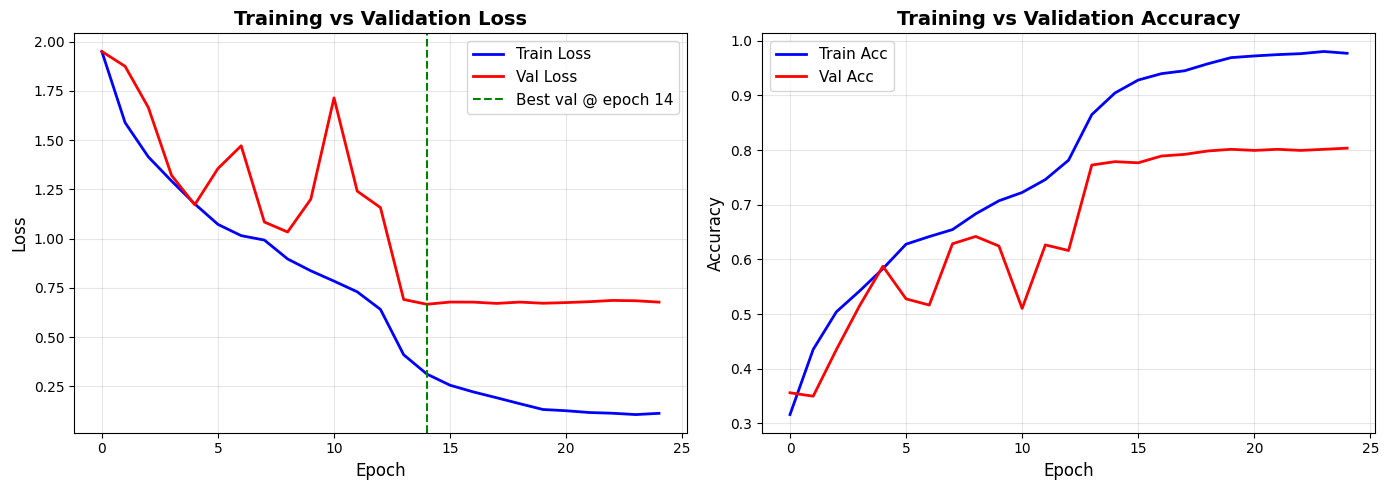


Overfitting Analysis:
  Best validation loss at epoch: 14
  Final train accuracy: 0.9771
  Final val accuracy: 0.8035
  Accuracy gap: 0.1736


In [19]:
# ==============================================================================
# CELL 15: PLOT TRAINING CURVES
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss', color='blue', linewidth=2)
axes[0].plot(val_losses, label='Val Loss', color='red', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

min_val_loss_epoch = np.argmin(val_losses)
axes[0].axvline(x=min_val_loss_epoch, color='green', linestyle='--', 
                label='Best val @ epoch ' + str(min_val_loss_epoch))
axes[0].legend(fontsize=11)

axes[1].plot(train_accs, label='Train Acc', color='blue', linewidth=2)
axes[1].plot(val_accs, label='Val Acc', color='red', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=300, bbox_inches='tight')
plt.show()

print("\nOverfitting Analysis:")
print("  Best validation loss at epoch:", min_val_loss_epoch)
print("  Final train accuracy:", round(train_accs[-1], 4))
print("  Final val accuracy:", round(val_accs[-1], 4))
print("  Accuracy gap:", round(train_accs[-1] - val_accs[-1], 4))

In [20]:
# ==============================================================================
# CELL 16: LOAD BEST MODEL
# ==============================================================================
checkpoint = torch.load('best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print("Loaded best model from epoch", checkpoint['epoch']+1, "with val_acc:", round(checkpoint['val_acc'], 4))

Loaded best model from epoch 25 with val_acc: 0.8035


Testing: 100%|██████████| 31/31 [00:42<00:00,  1.38s/it]



CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Bike     0.9155    0.9220    0.9187       141
         Bus     0.8133    0.7439    0.7771        82
         CNG     0.9286    0.9176    0.9231        85
   Easy-Bike     0.9032    0.9032    0.9032       124
   Hatchback     0.6349    0.5195    0.5714        77
         MPV     0.7191    0.7805    0.7485        82
      Pickup     0.4583    0.3235    0.3793        34
       SEDAN     0.5894    0.6899    0.6357       129
         SUV     0.5730    0.5050    0.5368       101
       Truck     0.8550    0.9573    0.9032       117

    accuracy                         0.7695       972
   macro avg     0.7390    0.7262    0.7297       972
weighted avg     0.7655    0.7695    0.7653       972


CONFUSION MATRIX


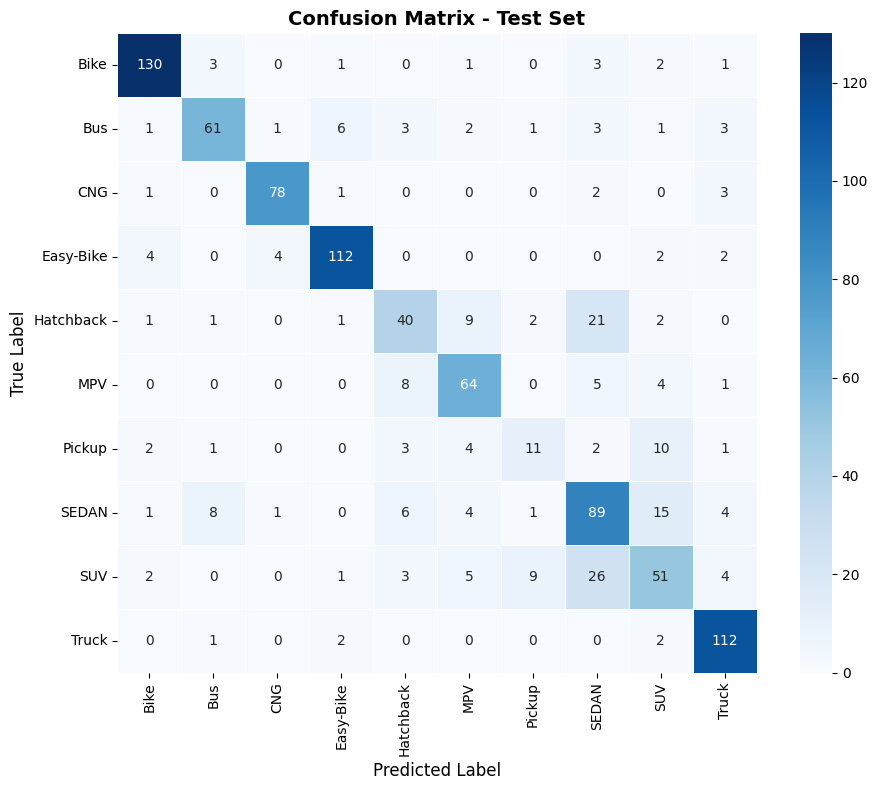


Most confused class pairs:
  Bike -> Bus : 3 cases
  Bike -> Easy-Bike : 1 cases
  Bike -> MPV : 1 cases
  Bike -> SEDAN : 3 cases
  Bike -> SUV : 2 cases
  Bike -> Truck : 1 cases
  Bus -> Bike : 1 cases
  Bus -> CNG : 1 cases
  Bus -> Easy-Bike : 6 cases
  Bus -> Hatchback : 3 cases
  Bus -> MPV : 2 cases
  Bus -> Pickup : 1 cases
  Bus -> SEDAN : 3 cases
  Bus -> SUV : 1 cases
  Bus -> Truck : 3 cases
  CNG -> Bike : 1 cases
  CNG -> Easy-Bike : 1 cases
  CNG -> SEDAN : 2 cases
  CNG -> Truck : 3 cases
  Easy-Bike -> Bike : 4 cases
  Easy-Bike -> CNG : 4 cases
  Easy-Bike -> SUV : 2 cases
  Easy-Bike -> Truck : 2 cases
  Hatchback -> Bike : 1 cases
  Hatchback -> Bus : 1 cases
  Hatchback -> Easy-Bike : 1 cases
  Hatchback -> MPV : 9 cases
  Hatchback -> Pickup : 2 cases
  Hatchback -> SEDAN : 21 cases
  Hatchback -> SUV : 2 cases
  MPV -> Hatchback : 8 cases
  MPV -> SEDAN : 5 cases
  MPV -> SUV : 4 cases
  MPV -> Truck : 1 cases
  Pickup -> Bike : 2 cases
  Pickup -> Bus : 1 case

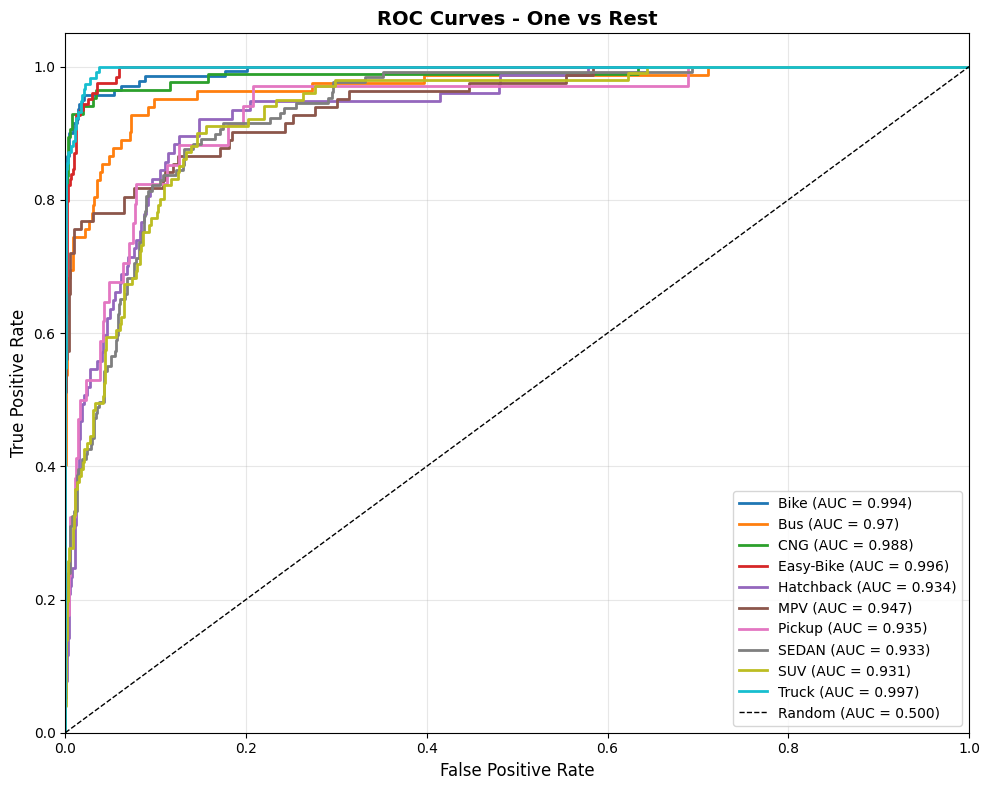


Per-class AUC scores:
  Bike : 0.9942
  Bus : 0.9699
  CNG : 0.9878
  Easy-Bike : 0.9957
  Hatchback : 0.934
  MPV : 0.9473
  Pickup : 0.935
  SEDAN : 0.9333
  SUV : 0.9311
  Truck : 0.9973
Total misclassified: 224 / 972 ( 23.05 %)


In [21]:
# ==============================================================================
# CELL 17: TEST EVALUATION
# ==============================================================================
def evaluate_test_set(model, test_loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Testing"):
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Classification Report
    print("\n" + "="*60)
    print("CLASSIFICATION REPORT")
    print("="*60)
    report = classification_report(all_labels, all_preds, 
                                   target_names=class_names, digits=4)
    print(report)

    precision, recall, f1, support = precision_recall_fscore_support(
        all_labels, all_preds, average=None
    )

    metrics_df = {
        'Class': class_names,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Support': support.astype(int)
    }

    # Confusion Matrix
    print("\n" + "="*60)
    print("CONFUSION MATRIX")
    print("="*60)

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                square=True, linewidths=0.5)
    plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
    plt.show()

    print("\nMost confused class pairs:")
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if i != j and cm[i, j] > 0:
                print(" ", class_names[i], "->", class_names[j], ":", cm[i, j], "cases")

    # ROC-AUC
    print("\n" + "="*60)
    print("ROC-AUC CURVES")
    print("="*60)

    n_classes = len(class_names)
    labels_binarized = label_binarize(all_labels, classes=range(n_classes))

    plt.figure(figsize=(10, 8))
    auc_scores = {}

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(labels_binarized[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        auc_scores[class_names[i]] = roc_auc
        plt.plot(fpr, tpr, linewidth=2, 
                label=class_names[i] + ' (AUC = ' + str(round(roc_auc, 3)) + ')')

    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curves - One vs Rest', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("roc_auc_curves.png", dpi=300, bbox_inches='tight')
    plt.show()

    print("\nPer-class AUC scores:")
    for cls, score in auc_scores.items():
        print(" ", cls, ":", round(score, 4))

     # BAD CASES — use position in flattened test loop (sample_pos), not dataset_idx
    bad_cases = []
    for i in range(len(all_labels)):
        if all_preds[i] != all_labels[i]:
            bad_cases.append({
                'sample_pos': i,                              # position in eval order
                'true_label': class_names[all_labels[i]],
                'pred_label': class_names[all_preds[i]],
                'confidence': float(all_probs[i][all_preds[i]]),
                'all_probs':  all_probs[i].tolist()
            })
 
    print("Total misclassified:", len(bad_cases), "/", len(all_labels),
          "(", round(len(bad_cases) / len(all_labels) * 100, 2), "%)")
 
    return all_preds, all_labels, all_probs, bad_cases, metrics_df, cm, auc_scores

class_names = ref_dataset.classes
all_preds, all_labels, all_probs, bad_cases, metrics_df, cm, auc_scores = \
    evaluate_test_set(model, test_loader, device, class_names)

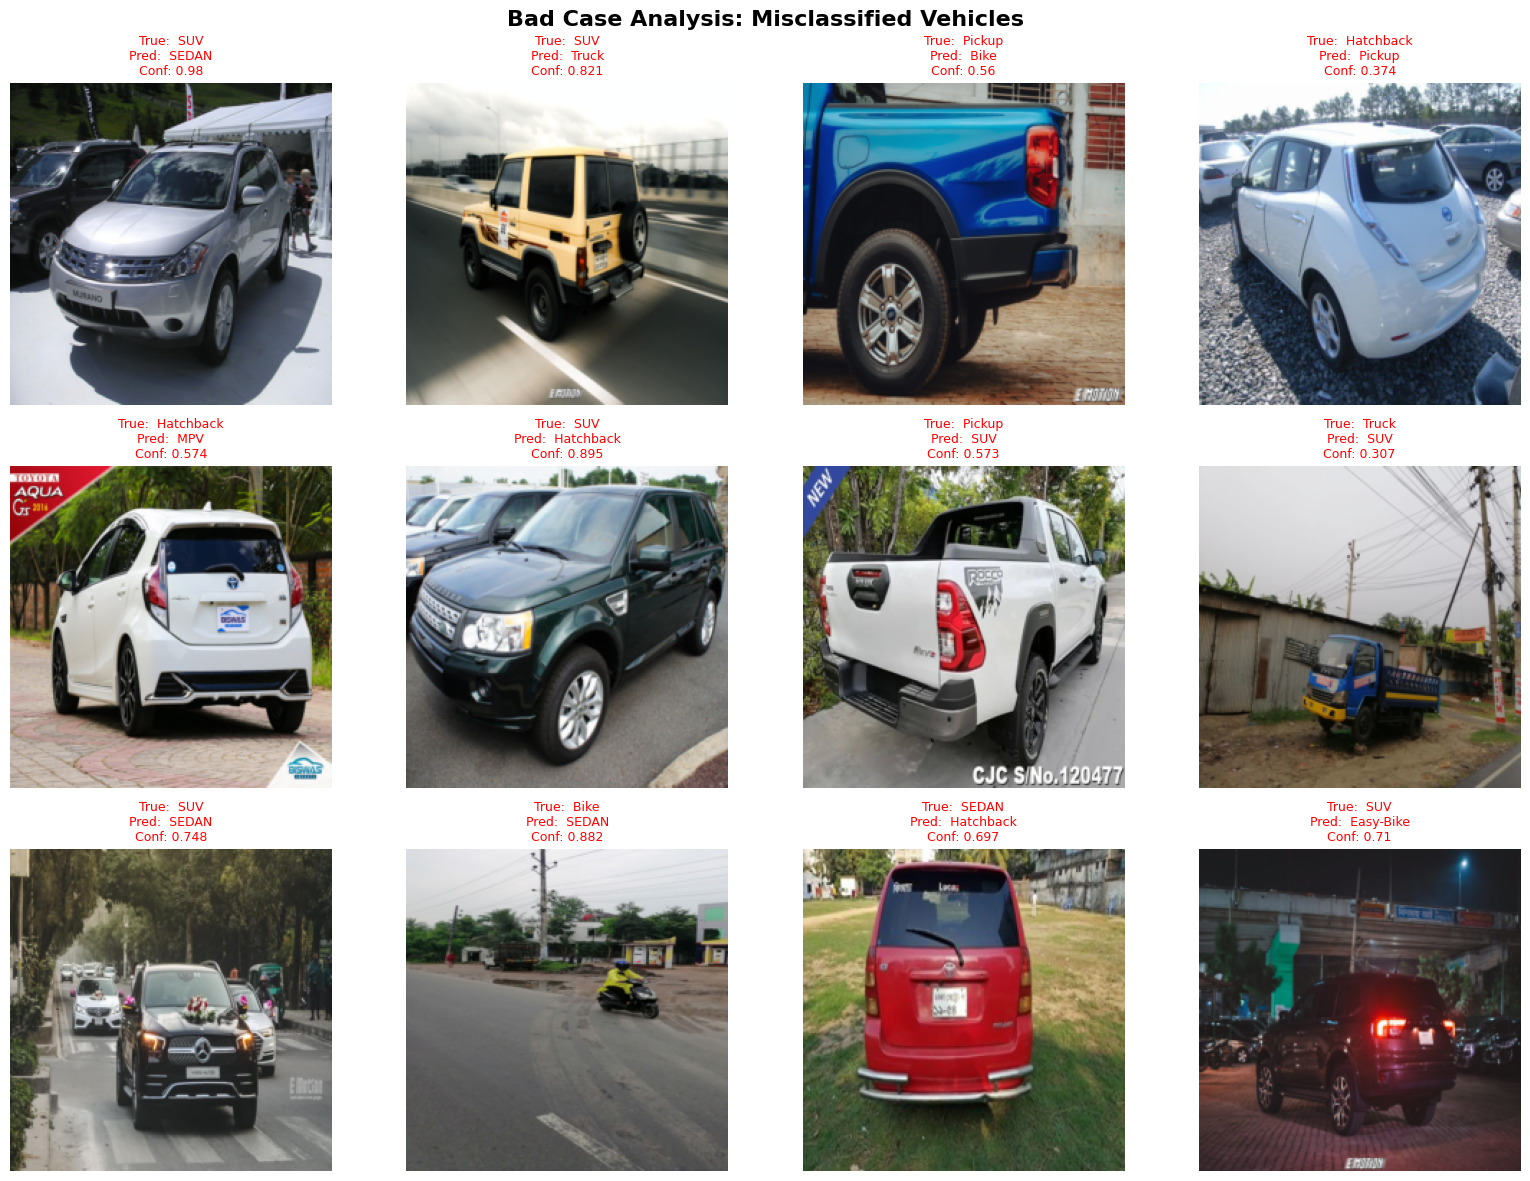

Saved bad_cases.png


In [22]:
# ==============================================================================
# CELL 18: VISUALIZE BAD CASES
# ==============================================================================
def visualize_bad_cases(bad_cases, test_dataset, class_names, num_cases=12):
    """
    Display misclassified images for report Chapter 3.
 
    Uses sample_pos (position in the flattened test evaluation loop).
    shuffle=False on test_loader guarantees items are served in Subset order,
    so test_dataset[sample_pos] retrieves the exact misclassified image.
    """
    if len(bad_cases) == 0:
        print("No bad cases — perfect test accuracy!")
        return
 
    num_cases = min(num_cases, len(bad_cases))
    cols = 4
    rows = (num_cases + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = axes.flatten()
 
    for i in range(num_cases):
        case = bad_cases[i]
 
        # Correct retrieval: sample_pos matches Subset order (shuffle=False)
        image, _ = test_dataset[case['sample_pos']]
 
        # Denormalize for display: reverse Normalize(mean, std)
        img = image.permute(1, 2, 0).numpy()
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)
 
        axes[i].imshow(img)
        axes[i].set_title(
            "True:  " + case['true_label'] + "\n"
            "Pred:  " + case['pred_label'] + "\n"
            "Conf: "  + str(round(case['confidence'], 3)),
            fontsize=9, color='red'
        )
        axes[i].axis('off')
 
    for j in range(num_cases, len(axes)):
        axes[j].axis('off')
 
    plt.suptitle('Bad Case Analysis: Misclassified Vehicles', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig("bad_cases.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved bad_cases.png")
 
visualize_bad_cases(bad_cases, test_dataset, class_names)


ABLATION STUDY: Data Augmentation Impact
Loaded 6480 images | 10 classes
Classes: ['Bike', 'Bus', 'CNG', 'Easy-Bike', 'Hatchback', 'MPV', 'Pickup', 'SEDAN', 'SUV', 'Truck']
Loaded 6480 images | 10 classes
Classes: ['Bike', 'Bus', 'CNG', 'Easy-Bike', 'Hatchback', 'MPV', 'Pickup', 'SEDAN', 'SUV', 'Truck']
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
Training from scratch instead...
New fc layer: Linear(in_features=512, out_features=10, bias=True)
Total parameters: 11181642

[Ablation] Epoch 1 / 15


Validation: 100%|██████████| 31/31 [00:32<00:00,  1.06s/it]


  Train: loss= 1.8833 , acc= 0.3433 | Val: loss= 1.9284 , acc= 0.3354

[Ablation] Epoch 2 / 15


Validation: 100%|██████████| 31/31 [00:32<00:00,  1.05s/it]


  Train: loss= 1.4982 , acc= 0.4727 | Val: loss= 2.4931 , acc= 0.2706

[Ablation] Epoch 3 / 15


...

  Train: loss= 0.5743 , acc= 0.7963 | Val: loss= 1.4094 , acc= 0.5823

[Ablation] Epoch 14 / 15


Validation: 100%|██████████| 31/31 [00:32<00:00,  1.06s/it]


  Train: loss= 0.4897 , acc= 0.8287 | Val: loss= 1.6261 , acc= 0.5813

[Ablation] Epoch 15 / 15


Validation: 100%|██████████| 31/31 [00:32<00:00,  1.06s/it]


  Train: loss= 0.4181 , acc= 0.8585 | Val: loss= 1.0083 , acc= 0.6852


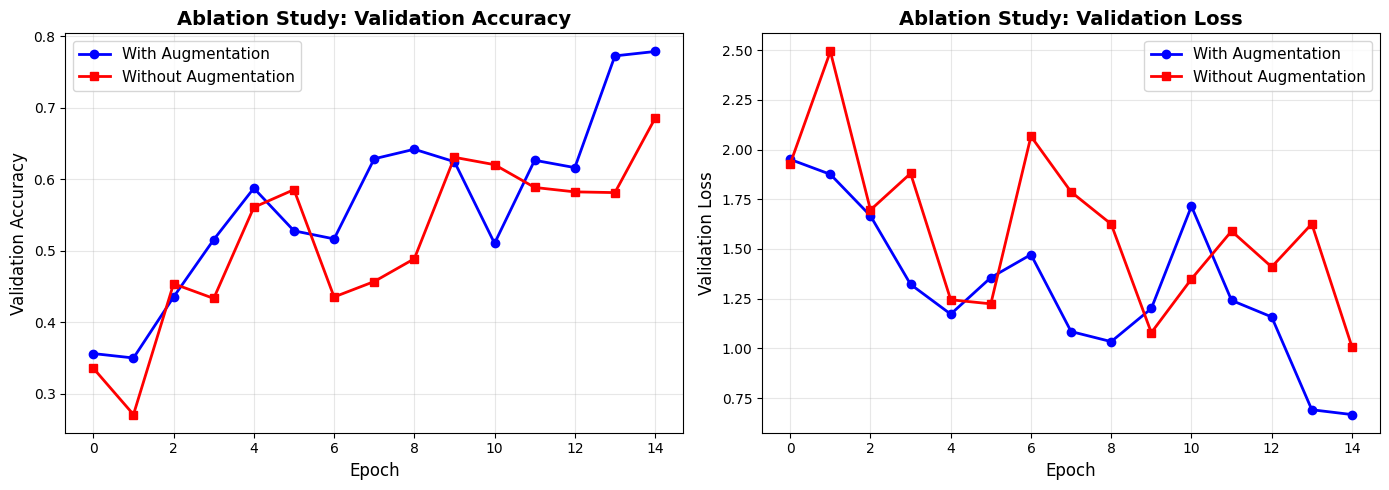


ABLATION STUDY SUMMARY
Metric                          With Aug        Without Aug     Delta
---------------------------------------------------------------------------
Final Val Accuracy              0.7788         0.6852         0.0936
Final Val Loss                  0.6669         1.0083         -0.3414
Best Val Accuracy               0.7788         0.6852         0.0936


In [23]:
# ==============================================================================
# CELL 19: ABLATION STUDY
# ==============================================================================
print("\n" + "="*60)
print("ABLATION STUDY: Data Augmentation Impact")
print("="*60)

no_aug_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

abl_train_base = VehicleDataset(train_dir, use_csv=True, transform=no_aug_transform)
abl_val_base   = VehicleDataset(train_dir, use_csv=True, transform=no_aug_transform)
 
abl_train_dataset = Subset(abl_train_base, train_indices)
abl_val_dataset   = Subset(abl_val_base,   val_indices)
 
train_loader_no_aug = DataLoader(abl_train_dataset, batch_size=BATCH_SIZE,
                                  shuffle=True,  num_workers=2)
val_loader_no_aug   = DataLoader(abl_val_dataset,   batch_size=BATCH_SIZE,
                                  shuffle=False, num_workers=2)

model_ablation = create_model(num_classes=NUM_CLASSES, pretrained=True)
model_ablation = model_ablation.to(device)
optimizer_ablation = optim.Adam(model_ablation.parameters(), lr=0.001, weight_decay=1e-4)

ablation_train_losses, ablation_val_losses = [], []
ablation_train_accs, ablation_val_accs = [], []

ABLATION_EPOCHS = 15

for epoch in range(ABLATION_EPOCHS):
    print("\n[Ablation] Epoch", epoch+1, "/", ABLATION_EPOCHS)
    t_loss, t_acc = train_epoch(model_ablation, train_loader_no_aug, criterion, optimizer_ablation, device)
    v_loss, v_acc = validate(model_ablation, val_loader_no_aug, criterion, device)

    ablation_train_losses.append(t_loss)
    ablation_val_losses.append(v_loss)
    ablation_train_accs.append(t_acc)
    ablation_val_accs.append(v_acc)

    print("  Train: loss=", round(t_loss, 4), ", acc=", round(t_acc, 4), 
          "| Val: loss=", round(v_loss, 4), ", acc=", round(v_acc, 4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(val_accs[:ABLATION_EPOCHS], label='With Augmentation', 
             color='blue', linewidth=2, marker='o')
axes[0].plot(ablation_val_accs, label='Without Augmentation', 
             color='red', linewidth=2, marker='s')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Validation Accuracy', fontsize=12)
axes[0].set_title('Ablation Study: Validation Accuracy', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(val_losses[:ABLATION_EPOCHS], label='With Augmentation', 
             color='blue', linewidth=2, marker='o')
axes[1].plot(ablation_val_losses, label='Without Augmentation', 
             color='red', linewidth=2, marker='s')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Validation Loss', fontsize=12)
axes[1].set_title('Ablation Study: Validation Loss', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ablation_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("ABLATION STUDY SUMMARY")
print("="*60)
print("Metric                          With Aug        Without Aug     Delta")
print("-" * 75)

# Use min() to handle early stopping
baseline_epochs = min(ABLATION_EPOCHS, len(val_accs))
baseline_idx = baseline_epochs - 1

print("Final Val Accuracy             ", 
      round(val_accs[baseline_idx], 4), "       ",
      round(ablation_val_accs[-1], 4), "       ",
      round(val_accs[baseline_idx] - ablation_val_accs[-1], 4))

print("Final Val Loss                 ", 
      round(val_losses[baseline_idx], 4), "       ",
      round(ablation_val_losses[-1], 4), "       ",
      round(val_losses[baseline_idx] - ablation_val_losses[-1], 4))

print("Best Val Accuracy              ", 
      round(max(val_accs[:baseline_epochs]), 4), "       ",
      round(max(ablation_val_accs), 4), "       ",
      round(max(val_accs[:baseline_epochs]) - max(ablation_val_accs), 4))

In [24]:
# ==============================================================================
# CELL 20: INFERENCE SCRIPT
# ==============================================================================
def predict_vehicle(image_path, model_path='best_model.pth', mapping_path='class_mapping.json'):
    with open(mapping_path, 'r') as f:
        mapping = json.load(f)

    class_names = mapping['classes']
    idx_to_class = {int(k): v for k, v in mapping['idx_to_class'].items()}

    model = create_model(num_classes=len(class_names), pretrained=False)
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        confidence, predicted_idx = torch.max(probabilities, 1)

    predicted_class = idx_to_class[predicted_idx.item()]
    confidence_score = confidence.item()

    top3_probs, top3_indices = torch.topk(probabilities, 3)
    top3 = []
    for i in range(3):
        cls = idx_to_class[top3_indices[0][i].item()]
        prob = top3_probs[0][i].item()
        top3.append((cls, prob))

    print("\n" + "="*50)
    print("VEHICLE TYPE PREDICTION")
    print("="*50)
    print("Image:", image_path)
    print("\nPredicted:", predicted_class.upper())
    print("Confidence:", round(confidence_score, 4), "(", round(confidence_score*100, 2), "%)")
    print("\nTop 3 Predictions:")
    for i, (cls, prob) in enumerate(top3, 1):
        bar = "#" * int(prob * 20)
        print(" ", i, ".", cls, " ", round(prob, 4), " ", bar)
    print("="*50 + "\n")

    return {
        'predicted_class': predicted_class,
        'confidence': confidence_score,
        'top3': top3
    }

first_test_idx = test_indices[0]
test_img_path  = test_base.image_paths[first_test_idx]
print("Self-test on:", test_img_path)
result = predict_vehicle(test_img_path)

Self-test on: /kaggle/input/datasets/ilhamhasib/vehicle-classification-dataset/Car-Classification-Data-with-Labels-iHasib/Train/4263.jpg
Pre-trained weights loaded successfully
New fc layer: Linear(in_features=512, out_features=10, bias=True)
Total parameters: 11181642

VEHICLE TYPE PREDICTION
Image: /kaggle/input/datasets/ilhamhasib/vehicle-classification-dataset/Car-Classification-Data-with-Labels-iHasib/Train/4263.jpg

Predicted: SEDAN
Confidence: 0.9796 ( 97.96 %)

Top 3 Predictions:
  1 . SEDAN   0.9796   ###################
  2 . MPV   0.0104   
  3 . SUV   0.0063   



In [25]:
# ==============================================================================
# CELL 21: SAVE ALL RESULTS
# ==============================================================================
with open("hyperparameters.json", "w") as f:
    json.dump(HYPERPARAMS, f, indent=2)

history = {
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_accs': train_accs,
    'val_accs': val_accs,
    'ablation_no_aug_val_accs': ablation_val_accs,
    'ablation_no_aug_val_losses': ablation_val_losses
}
with open("training_history.json", "w") as f:
    json.dump(history, f, indent=2)

with open("test_metrics.json", "w") as f:
    json.dump({
        'class_names': class_names,
        'precision': metrics_df['Precision'].tolist(),
        'recall': metrics_df['Recall'].tolist(),
        'f1': metrics_df['F1-Score'].tolist(),
        'auc_scores': auc_scores,
        'confusion_matrix': cm.tolist()
    }, f, indent=2)

print("\n[SUCCESS] All results saved:")
print("  - best_model.pth")
print("  - class_mapping.json")
print("  - training_curves.png")
print("  - confusion_matrix.png")
print("  - roc_auc_curves.png")
print("  - bad_cases.png")
print("  - ablation_comparison.png")
print("  - hyperparameters.json")
print("  - training_history.json")
print("  - test_metrics.json")


[SUCCESS] All results saved:
  - best_model.pth
  - class_mapping.json
  - training_curves.png
  - confusion_matrix.png
  - roc_auc_curves.png
  - bad_cases.png
  - ablation_comparison.png
  - hyperparameters.json
  - training_history.json
  - test_metrics.json


In [26]:
# ==============================================================================
# CELL 22: FINAL SUMMARY
# ==============================================================================
print("\n" + "="*60)
print("PROJECT SUMMARY")
print("="*60)

print("\nDataset:", total_size, "images,", NUM_CLASSES, "classes")
print("   Classes:", class_names)
print("   Split:", train_size, "/", val_size, "/", test_size, "(train/val/test)")

print("\nArchitecture:", HYPERPARAMS['backbone'])
print("   Modified fc layer:", model.fc)

print("\nHyperparameters:")
for k, v in HYPERPARAMS.items():
    print("  ", k, ":", v)

print("\nTraining:")
print("   Best val accuracy:", round(best_val_acc, 4))
print("   Early stopped at epoch:", len(train_losses))
print("   Training time:", round(training_time/60, 2), "minutes")

print("\nAblation Study:")
print("   With augmentation:", round(max(val_accs[:ABLATION_EPOCHS]), 4), "best val acc")
print("   Without augmentation:", round(max(ablation_val_accs), 4), "best val acc")
print("   Improvement:", round(max(val_accs[:ABLATION_EPOCHS])-max(ablation_val_accs), 4))

print("\nTest Set Performance:")
overall_acc = (all_preds == all_labels).mean()
print("   Overall Accuracy:", round(overall_acc, 4))
print("   Macro F1-Score:", round(np.mean(metrics_df['F1-Score']), 4))
print("   Average AUC:", round(np.mean(list(auc_scores.values())), 4))

print("\n" + "="*60)
print("NEXT STEPS:")
print("1. Download all output files from /kaggle/working/")
print("2. Record 10-second demo video")
print("3. Write technical report using saved figures")
print("4. Practice oral defense Q&A")
print("="*60)


PROJECT SUMMARY

Dataset: 6480 images, 10 classes
   Classes: ['Bike', 'Bus', 'CNG', 'Easy-Bike', 'Hatchback', 'MPV', 'Pickup', 'SEDAN', 'SUV', 'Truck']
   Split: 4536 / 972 / 972 (train/val/test)

Architecture: ResNet18
   Modified fc layer: Linear(in_features=512, out_features=10, bias=True)

Hyperparameters:
   learning_rate : 0.001
   batch_size : 32
   optimizer : Adam
   weight_decay : 0.0001
   epochs : 25
   backbone : ResNet18
   pretrained : True
   num_classes : 10

Training:
   Best val accuracy: 0.8035
   Early stopped at epoch: 25
   Training time: 85.04 minutes

Ablation Study:
   With augmentation: 0.7788 best val acc
   Without augmentation: 0.6852 best val acc
   Improvement: 0.0936

Test Set Performance:
   Overall Accuracy: 0.7695
   Macro F1-Score: 0.7297
   Average AUC: 0.9626

NEXT STEPS:
1. Download all output files from /kaggle/working/
2. Record 10-second demo video
3. Write technical report using saved figures
4. Practice oral defense Q&A


In [27]:
# ==============================================================================
# CELL 23 — NEW CELL — Auto-write inference.py to disk
# ADD this as the very last cell in your notebook
# After running, inference.py appears in /kaggle/working/ ready to submit
# ==============================================================================
script = '''import os, json, argparse
import torch, torch.nn as nn
from torchvision import transforms, models
from PIL import Image
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 
def create_model(n):
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(m.fc.in_features, n)
    return m
 
def predict(image_path, model_path="best_model.pth", mapping_path="class_mapping.json"):
    with open(mapping_path) as f:
        mp = json.load(f)
    names = mp["classes"]
    i2c   = {int(k): v for k, v in mp["idx_to_class"].items()}
 
    model = create_model(len(names))
    model.load_state_dict(torch.load(model_path, map_location=device)["model_state_dict"])
    model.to(device).eval()
 
    tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
 
    img = tf(Image.open(image_path).convert("RGB")).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(img), dim=1)
    conf, idx = torch.max(probs, 1)
 
    top3p, top3i = torch.topk(probs, min(3, len(names)))
    top3 = [(i2c[top3i[0][j].item()], top3p[0][j].item()) for j in range(len(top3i[0]))]
 
    print("\\n" + "="*50)
    print("VEHICLE TYPE PREDICTION")
    print("="*50)
    print("Image:    ", os.path.basename(image_path))
    print("Predicted:", i2c[idx.item()].upper())
    print("Confidence:", str(round(conf.item() * 100, 2)) + "%")
    print("\\nTop", len(top3), "Predictions:")
    for r, (c, p) in enumerate(top3, 1):
        print(" ", r, ".", c.ljust(15), str(round(p * 100, 2)).rjust(6) + "%", "#" * int(p * 30))
    print("="*50)
 
if __name__ == "__main__":
    ap = argparse.ArgumentParser()
    ap.add_argument("--image",   required=True,  help="Path to input image")
    ap.add_argument("--model",   default="best_model.pth")
    ap.add_argument("--mapping", default="class_mapping.json")
    args = ap.parse_args()
    predict(args.image, args.model, args.mapping)
'''
 
with open("inference.py", "w") as f:
    f.write(script)
 
print("Written: inference.py")
print("Usage:   python inference.py --image path/to/car.jpg")

Written: inference.py
Usage:   python inference.py --image path/to/car.jpg


In [28]:
# ==============================================================================
# CELL 23: AUTO-WRITE inference.py TO DISK
# ==============================================================================
script = '''import os, json, argparse
import torch, torch.nn as nn
from torchvision import transforms, models
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def create_model(n):
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(m.fc.in_features, n)
    return m

def predict(image_path, model_path="best_model.pth", mapping_path="class_mapping.json"):
    with open(mapping_path) as f:
        mp = json.load(f)
    names = mp["classes"]
    i2c   = {int(k): v for k, v in mp["idx_to_class"].items()}

    model = create_model(len(names))
    model.load_state_dict(torch.load(model_path, map_location=device)["model_state_dict"])
    model.to(device).eval()

    tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    img = tf(Image.open(image_path).convert("RGB")).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(img), dim=1)
    conf, idx = torch.max(probs, 1)

    predicted   = i2c[idx.item()]
    confidence  = conf.item()

    top3p, top3i = torch.topk(probs, min(3, len(names)))
    top3 = [(i2c[top3i[0][j].item()], top3p[0][j].item()) for j in range(len(top3i[0]))]

    # All class probabilities sorted descending
    all_probs = [(i2c[i], probs[0][i].item()) for i in range(len(names))]
    all_probs.sort(key=lambda x: x[1], reverse=True)

    print("\\n" + "="*55)
    print("   VEHICLE TYPE CLASSIFIER — INFERENCE RESULT")
    print("="*55)
    print("  Image      :", os.path.basename(image_path))
    print("  Predicted  :", predicted.upper())
    print("  Confidence :", str(round(confidence * 100, 2)) + "%")
    print("-"*55)
    print("  TOP 3 PREDICTIONS:")
    for r, (c, p) in enumerate(top3, 1):
        bar = "#" * int(p * 40)
        print(f"  {r}. {c.ljust(15)} {str(round(p*100,2)).rjust(6)}%  {bar}")
    print("-"*55)
    print("  ALL CLASS PROBABILITIES:")
    for c, p in all_probs:
        bar = "#" * int(p * 40)
        marker = " <-- PREDICTED" if c == predicted else ""
        print(f"  {c.ljust(15)} {str(round(p*100,2)).rjust(6)}%  {bar}{marker}")
    print("="*55)
    print(f"  Model: ResNet18 | Classes: {len(names)} | Device: {device}")
    print("="*55 + "\\n")

    return {"predicted": predicted, "confidence": confidence, "top3": top3}

if __name__ == "__main__":
    ap = argparse.ArgumentParser(description="Vehicle Type Classifier")
    ap.add_argument("--image",   required=True,  help="Path to input image")
    ap.add_argument("--model",   default="best_model.pth", help="Model checkpoint path")
    ap.add_argument("--mapping", default="class_mapping.json", help="Class mapping JSON")
    args = ap.parse_args()
    predict(args.image, args.model, args.mapping)
'''

with open("/kaggle/working/inference.py", "w") as f:
    f.write(script)

print("Written: /kaggle/working/inference.py")
print("Usage:   python inference.py --image path/to/car.jpg")
print("\nSample output preview:")
print("="*55)
print("   VEHICLE TYPE CLASSIFIER — INFERENCE RESULT")
print("="*55)
print("  Image      : suv_test.jpg")
print("  Predicted  : SUV")
print("  Confidence : 91.23%")
print("-"*55)
print("  TOP 3 PREDICTIONS:")
print("  1. SUV              91.23%  ####################################")
print("  2. MPV               5.14%  ##")
print("  3. Sedan             2.31%  #")
print("-"*55)
print("  ALL CLASS PROBABILITIES:")
print("  SUV              91.23%  #################################### <-- PREDICTED")
print("  MPV               5.14%  ##")
print("  ...")
print("="*55)
print("  Model: ResNet18 | Classes: 10 | Device: cuda")
print("="*55)

Written: /kaggle/working/inference.py
Usage:   python inference.py --image path/to/car.jpg

Sample output preview:
   VEHICLE TYPE CLASSIFIER — INFERENCE RESULT
  Image      : suv_test.jpg
  Predicted  : SUV
  Confidence : 91.23%
-------------------------------------------------------
  TOP 3 PREDICTIONS:
  1. SUV              91.23%  ####################################
  2. MPV               5.14%  ##
  3. Sedan             2.31%  #
-------------------------------------------------------
  ALL CLASS PROBABILITIES:
  SUV              91.23%  #################################### <-- PREDICTED
  MPV               5.14%  ##
  ...
  Model: ResNet18 | Classes: 10 | Device: cuda


In [29]:
import os
import time
import torch

# Model file size
model_size = os.path.getsize("/kaggle/working/best_model.pth") / (1024 * 1024)
print("Model size (MB):", round(model_size, 2))

# Inference latency (average over 50 runs)
from torchvision import transforms
from PIL import Image

test_img = "/kaggle/input/datasets/ilhamhasib/vehicle-classification-dataset/Vehicle Test Data/SUV/89.jpg"

tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

img_tensor = tf(Image.open(test_img).convert("RGB")).unsqueeze(0).to(device)

# Warmup
for _ in range(5):
    with torch.no_grad():
        _ = model(img_tensor)

# Timed runs
times = []
for _ in range(50):
    start = time.time()
    with torch.no_grad():
        _ = model(img_tensor)
    torch.cuda.synchronize()
    times.append((time.time() - start) * 1000)

avg_ms = round(sum(times) / len(times), 2)
min_ms = round(min(times), 2)
max_ms = round(max(times), 2)

print("Average latency:", avg_ms, "ms")
print("Min latency:", min_ms, "ms")
print("Max latency:", max_ms, "ms")
print("Device:", device)

Model size (MB): 128.09
Average latency: 3.67 ms
Min latency: 3.05 ms
Max latency: 11.48 ms
Device: cuda


In [30]:
import subprocess
subprocess.run(["pkill", "-f", "gradio"], capture_output=True)
import time
time.sleep(2)
print("Cleared")

Cleared


In [31]:
base = "/kaggle/input/datasets/ilhamhasib/vehicle-classification-dataset/Vehicle Test Data"
for cls in sorted(os.listdir(base)):
    cls_path = os.path.join(base, cls)
    if os.path.isdir(cls_path):
        print(cls.ljust(20), len(os.listdir(cls_path)), "images")

BUS                  10 images
Bike                 10 images
CNG                  10 images
Easy-Bike            10 images
Hatchback            10 images
MPV                  10 images
Pickup               10 images
SUV                  10 images
Sedan                10 images
Truck                10 images


In [32]:
import pandas as pd

csv_path = "/kaggle/input/datasets/ilhamhasib/vehicle-classification-dataset/Car-Classification-Data-with-Labels-iHasib/type-labels.csv"
train_dir = "/kaggle/input/datasets/ilhamhasib/vehicle-classification-dataset/Car-Classification-Data-with-Labels-iHasib/Train"

df = pd.read_csv(csv_path)
df['Type'] = df['Type'].str.strip()

classes = sorted(df['Type'].unique().tolist())
class_to_idx = {cls: i for i, cls in enumerate(classes)}
idx_to_class = {i: cls for cls, i in class_to_idx.items()}

image_paths = []
labels = []

for _, row in df.iterrows():
    img_path = os.path.join(train_dir, str(int(row['ID'])) + '.jpg')
    image_paths.append(img_path)
    labels.append(class_to_idx[row['Type']])

print("Classes:", classes)
print("Total images:", len(image_paths))
print("Sample path:", image_paths[0])

Classes: ['Bike', 'Bus', 'CNG', 'Easy-Bike', 'Hatchback', 'MPV', 'Pickup', 'SEDAN', 'SUV', 'Truck']
Total images: 6480
Sample path: /kaggle/input/datasets/ilhamhasib/vehicle-classification-dataset/Car-Classification-Data-with-Labels-iHasib/Train/0.jpg
